# 任务三：过拟合现象观察实验（以决策树为例）

这个 notebook 的核心目标是：

只改变 `DecisionTreeClassifier` 的 `max_depth`，
观察模型复杂度变化时，训练集准确率和测试集准确率分别如何变化。

这正是“欠拟合 - 合适拟合 - 过拟合”现象最经典的观察方式之一。

## 第 1 步：导入库并准备数据

这一格中我们会：

- 导入实验所需的库；
- 加载 Iris 数据集；
- 按 7:3 划分训练集和测试集；
- 设置不同的 `max_depth` 候选值。

In [1]:
# 忽略警告，让 notebook 输出更简洁
import warnings
warnings.filterwarnings("ignore")

# 导入基础库和绘图库
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 设置图表风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42

# 加载 Iris 数据
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

# 按 7:3 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 实验题给定的树深度取值范围
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]

## 第 2 步：遍历不同深度，记录训练集和测试集准确率

这里是本实验最关键的一步。

我们会让决策树从“很浅”逐步变到“很深”，
并在每个深度下记录：

- 训练集准确率；
- 测试集准确率。

这样就能看到模型复杂度变化对泛化能力的影响。

In [2]:
# 用来保存不同深度下的实验结果
records = []

for depth in depth_values:
    # 构造当前深度下的决策树模型
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)

    # 在训练集上训练
    clf.fit(X_train, y_train)

    # 分别对训练集和测试集做预测
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)

    # 记录当前深度下的准确率
    records.append(
        {
            "max_depth": "None" if depth is None else depth,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred),
        }
    )

# 整理成表格，便于查看每一个深度的结果
score_df = pd.DataFrame(records)
display(score_df)

,max_depth,train_accuracy,test_accuracy
0,1,0.666667,0.666667
1,2,0.971429,0.888889
2,3,0.980952,0.977778
3,4,0.990476,0.888889
4,5,1.000000,0.933333
5,6,1.000000,0.933333
6,7,1.000000,0.933333
7,8,1.000000,0.933333
8,9,1.000000,0.933333
9,10,1.000000,0.933333


## 第 3 步：绘制“模型复杂度 vs 准确率”曲线

这张图是本实验最重要的结果图。

读图时可以重点关注：

- 训练集准确率是否随深度持续上升；
- 测试集准确率何时达到最高；
- 深度继续增加后，测试集准确率是否开始下降。

如果出现“训练集越来越好，但测试集反而变差”，这通常就是过拟合。

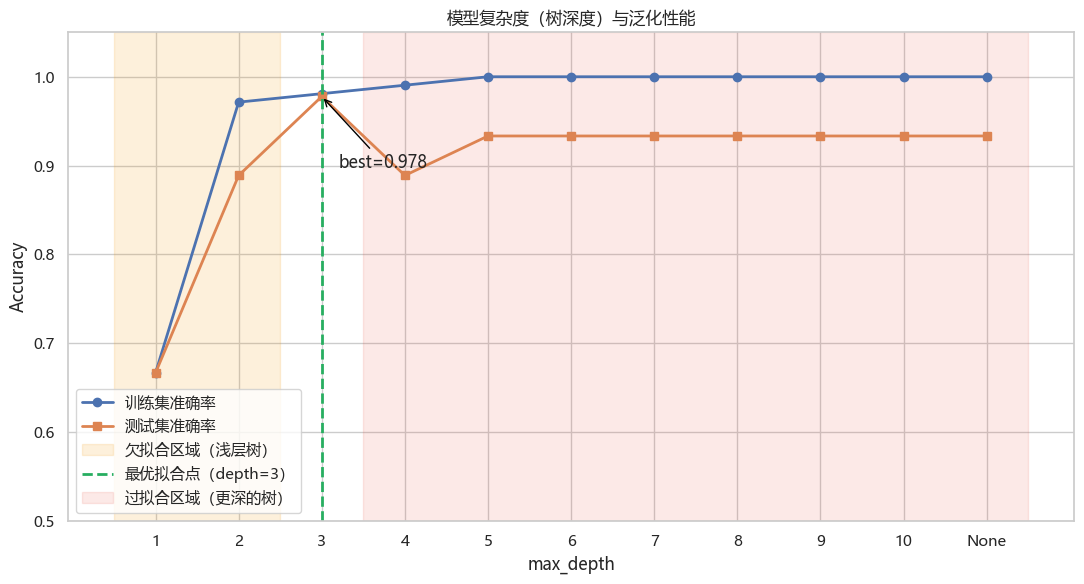

In [3]:
# 横坐标位置和显示标签分开处理，便于把 None 也画到图上
x_positions = list(range(1, len(score_df) + 1))
depth_labels = score_df["max_depth"].astype(str).tolist()

# 找到测试集准确率最高的位置，作为“最优拟合点”
best_idx = score_df["test_accuracy"].idxmax()
best_position = x_positions[best_idx]
best_depth = depth_labels[best_idx]
best_score = score_df.loc[best_idx, "test_accuracy"]

plt.figure(figsize=(11, 6))

# 画训练集和测试集两条曲线
plt.plot(x_positions, score_df["train_accuracy"], marker="o", linewidth=2, label="训练集准确率")
plt.plot(x_positions, score_df["test_accuracy"], marker="s", linewidth=2, label="测试集准确率")

# 标出欠拟合区域：一般出现在树非常浅的时候
plt.axvspan(0.5, 2.5, color="#f39c12", alpha=0.15, label="欠拟合区域（浅层树）")

# 标出测试集表现最好的位置
plt.axvline(best_position, color="#27ae60", linestyle="--", linewidth=2, label=f"最优拟合点（depth={best_depth}）")

# 如果最优点后面还有更深的树，就把右侧区域近似标成过拟合区
if best_position < x_positions[-1]:
    plt.axvspan(best_position + 0.5, x_positions[-1] + 0.5, color="#e74c3c", alpha=0.12, label="过拟合区域（更深的树）")

# 给最优点加一个文字标注
plt.annotate(
    f"best={best_score:.3f}",
    xy=(best_position, best_score),
    xytext=(best_position + 0.2, best_score - 0.08),
    arrowprops={"arrowstyle": "->", "color": "black"},
)

plt.xticks(x_positions, depth_labels)
plt.ylim(0.5, 1.05)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("模型复杂度（树深度）与泛化性能")
plt.legend()
plt.tight_layout()
plt.show()

## 实验结论参考写法

报告里可以这样解释曲线变化：

- 当树深度很小时，模型太简单，无法充分学习数据规律，所以训练集和测试集准确率都不高，这属于欠拟合。
- 随着深度增加，模型表达能力变强，测试集准确率通常会上升。
- 当深度继续增加时，训练集准确率可能接近 1，但测试集准确率不一定继续提高，甚至下降，这说明模型开始记住训练样本细节，出现过拟合。
- 这正体现了偏差-方差权衡：模型太简单时偏差大，模型太复杂时方差大。